# Base Networks Comparison Analysis

In [30]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [31]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_base2_"


# Paths to the three networks
network_paths = {
    #"windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    #"windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}


# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
#n1 = networks["windy"]
n2 = networks["notwindy"]
#n3 = networks["windvariability"]

#n1.name = "Windy"
n2.name = "Not Windy"
#n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


### Check

In [4]:
# --- Verification Step: Check if lines were extended ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines:
        if n.lines.s_nom.equals(n.lines.s_nom_opt):
            print(f"Verification PASSED for '{name}' network: Line capacities were not extended (s_nom equals s_nom_opt).")
        else:
            diff_count = (n.lines.s_nom != n.lines.s_nom_opt).sum()
            print(f"Verification FAILED for '{name}' network: {diff_count} lines have different s_nom and s_nom_opt.")
    else:
        print(f"Verification NOTE for '{name}' network: No 's_nom_opt' column found; assuming lines were not extendable.")

Verification FAILED for 'notwindy' network: 628 lines have different s_nom and s_nom_opt.


In [5]:
# --- Fix Step: If verification fails, disable line extension on the base network ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines and not n.lines.s_nom.equals(n.lines.s_nom_opt):
        print(f"Fixing base network for '{name}'...")
        
        # Construct the path to the original base network in the 'resources' directory
        folder_name = f"germany_base_{name}"
        base_network_path = f"{home}/pypsa-eur/resources/{folder_name}/networks/base_s_{cluster}_elec_.nc"
        
        # Check if the file exists before trying to modify it
        if not os.path.exists(base_network_path):
            print(f"ERROR: Base network file not found at {base_network_path}. Skipping fix.")
            continue

        # Load the original base network
        base_n = pypsa.Network(base_network_path)
        
        # Set s_nom_extendable to False
        for component in base_n.iterate_components(["Line", "Link"]):
            if "s_nom_extendable" in component.df.columns:
                component.df["s_nom_extendable"] = False
            
        # Save the corrected network back to its original location
        base_n.export_to_netcdf(base_network_path)
        print(f"'{name}' base network at {base_network_path} has been updated to disable line extensions.")
        print("Warning: Remember to rerun solve to apply the changes!")

Fixing base network for 'notwindy'...


INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
/tmp/ipykernel_21818/2185024867.py:19: DeprecatedWarning: iterate_components is deprecated as of 1.0.0 and will be removed in 2.0.0. Use `for component in n.components` instead.
  for component in base_n.iterate_components(["Line", "Link"]):
/tmp/ipykernel_21818/2185024867.py:20: DeprecatedWarning: df is deprecated as of 1.0.0 and will be removed in 2.0.0. Use `c.static` instead.
  if "s_nom_extendable" in component.df.columns:
/tmp/ipykernel_21818/2185024867.py:21: DeprecatedWarning: df is deprecated as of 1.0.0 and will be removed in 2.0.0. Use `c.static` instead.
  component.df["s_nom_extendable"] = False
INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to '/home/lucakristin/Desktop/my_pypsa/pypsa-eur/resources/germany_base_notwindy/networks/base_s_450_elec_

'notwindy' base network at /home/lucakristin/Desktop/my_pypsa/pypsa-eur/resources/germany_base_notwindy/networks/base_s_450_elec_.nc has been updated to disable line extensions.


In [14]:
n1.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04   
            Offshore Wind (AC)        1.116374e+04        1.116374e+04   
            Onshore Wind              7.333207e+04        7.333207e+04   
            Open-Cycle Gas            6.112744e+03        6.112744e+03   
            Run of River              4.014119e+03        4.014119e+03   
            Solar                     4.877125e+04        4.877125e+04   
            biomass                   8.020002e+03        8.020002e+03   
            coal                      2.035194e+04        2.035194e+04   
            geothermal                2.690000e+01        2.690000e+01   
            lignite                   1.945703e+04        1.945703e+04   
            oil                       5.684346e+03        5.684346e+03   
            waste                     3.127659e+03        3.127659e+03   
Line        AC                        1.507647e+06        1.507647e+06   
Link        H2 Electrolysis           1.806179e+02        0.000000e+00   
            H2 Fuel Cell              7.447056e+02        0.000000e+00   
            battery charger           2.497960e+02        0.000000e+00   
            battery discharger        2.549469e+02        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           2.785833e+02        0.000000e+00   
            Hydrogen Storage          1.663022e+03        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    4.807000e-02  0.000000e+00    4.807000e-02   
            Offshore Wind (AC)    2.490658e+04  0.000000e+00    2.490658e+04   
            Onshore Wind          1.020955e+06  0.000000e+00    1.020955e+06   
            Open-Cycle Gas        5.547000e-02  0.000000e+00    5.547000e-02   
            Run of River          3.950972e+04  0.000000e+00    3.950972e+04   
            Solar                 6.549729e+04  0.000000e+00    6.549729e+04   
            biomass               1.407690e+04  0.000000e+00    1.407690e+04   
            coal                  5.365307e+04  0.000000e+00    5.365307e+04   
            geothermal            4.673510e+02  0.000000e+00    4.673510e+02   
            lignite               8.700000e-03  0.000000e+00    8.700000e-03   
            oil                   2.243000e-02  0.000000e+00    2.243000e-02   
            waste                 1.220310e+02  0.000000e+00    1.220310e+02   
Line        AC                    4.226340e+06  4.333443e+06   -1.071029e+05   
Link        H2 Electrolysis       0.000000e+00  4.334648e+03   -4.334648e+03   
            H2 Fuel Cell          0.000000e+00  3.031653e+03   -3.031653e+03   
            battery charger       0.000000e+00  5.348002e+03   -5.348002e+03   
            battery discharger    0.000000e+00  5.239950e+03   -5.239950e+03   
Load        -                     0.000000e+00  1.179665e+06   -1.179665e+06   
StorageUnit Pumped Hydro Storage  1.998976e+04  2.746215e+04   -7.472389e+03   
            Reservoir & Dam       2.942387e+03  0.000000e+00    2.942387e+03   
Store       Battery Storage       7.825939e+02  7.825939e+02    0.000000e+00   
            Hydrogen Storage      1.789155e+03  1.789155e+03    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000     6.497065e-08  738795.03185   
            Offshore Wind (AC)         0.00000     9.295934e-02  211310.89957   
            Onshore Wind               0.00000     5.800978e-01  499821.67390   
            Open-Cycle Gas             0.00000     3.778990e-07  146705.79388   
            Run of River               0.00000     4.101120e-01     569.66604   
    

In [10]:
n2.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04   
            Offshore Wind (AC)        1.116374e+04        1.116374e+04   
            Onshore Wind              7.333207e+04        7.333207e+04   
            Open-Cycle Gas            6.112744e+03        6.112744e+03   
            Run of River              4.014119e+03        4.014119e+03   
            Solar                     4.877125e+04        4.877125e+04   
            biomass                   8.020002e+03        8.020002e+03   
            coal                      2.035194e+04        2.035194e+04   
            geothermal                2.690000e+01        2.690000e+01   
            lignite                   1.945703e+04        1.945703e+04   
            load                               inf                 inf   
            oil                       5.684346e+03        5.684346e+03   
            waste                     3.127659e+03        3.127659e+03   
Line        AC                        1.507800e+06        1.507647e+06   
Link        H2 Electrolysis           5.038210e+00        0.000000e+00   
            H2 Fuel Cell              4.296000e-02        0.000000e+00   
            battery charger           1.162873e+04        0.000000e+00   
            battery discharger        1.186852e+04        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           4.603107e+04        0.000000e+00   
            Hydrogen Storage          1.384132e+04        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    6.030924e+05  0.000000e+00    6.030924e+05   
            Offshore Wind (AC)    8.316628e+03  0.000000e+00    8.316628e+03   
            Onshore Wind          4.943532e+04  0.000000e+00    4.943532e+04   
            Open-Cycle Gas        1.685630e+00  0.000000e+00    1.685630e+00   
            Run of River          6.387179e+04  0.000000e+00    6.387179e+04   
            Solar                 2.473224e+05  0.000000e+00    2.473224e+05   
            biomass               1.924799e+05  0.000000e+00    1.924799e+05   
            coal                  1.419000e-02  0.000000e+00    1.419000e-02   
            geothermal            6.455974e+02  0.000000e+00    6.455974e+02   
            lignite               6.720000e-03  0.000000e+00    6.720000e-03   
            load                  1.392547e+05  0.000000e+00    1.392547e+05   
            oil                   2.285000e-01  0.000000e+00    2.285000e-01   
            waste                 4.762000e-02  0.000000e+00    4.762000e-02   
Line        AC                    1.180832e+06  1.273104e+06   -9.227232e+04   
Link        H2 Electrolysis       0.000000e+00  4.321500e-01   -4.321500e-01   
            H2 Fuel Cell          0.000000e+00  9.896400e-01   -9.896400e-01   
            battery charger       0.000000e+00  4.736199e+04   -4.736199e+04   
            battery discharger    0.000000e+00  4.641295e+04   -4.641295e+04   
Load        -                     0.000000e+00  1.300023e+06   -1.300023e+06   
StorageUnit Pumped Hydro Storage  1.000000e-04  1.834000e-02   -1.824000e-02   
            Reservoir & Dam       5.760283e+03  0.000000e+00    5.760283e+03   
Store       Battery Storage       4.640228e+04  4.640228e+04    0.000000e+00   
            Hydrogen Storage      1.933000e-02  1.933000e-02    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000     8.163189e-01  1.357027e+05   
            Offshore Wind (AC)         0.00000     3.104032e-02  1.120000e-03   
            Onshore Wind               0.00000     2.808873e-02  8.240000e-02   
            

In [16]:
n3.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04   
            Offshore Wind (AC)        1.116374e+04        1.116374e+04   
            Onshore Wind              7.333207e+04        7.333207e+04   
            Open-Cycle Gas            6.112744e+03        6.112744e+03   
            Run of River              4.014119e+03        4.014119e+03   
            Solar                     4.877125e+04        4.877125e+04   
            biomass                   8.020002e+03        8.020002e+03   
            coal                      2.035194e+04        2.035194e+04   
            geothermal                2.690000e+01        2.690000e+01   
            lignite                   1.945703e+04        1.945703e+04   
            oil                       5.684346e+03        5.684346e+03   
            waste                     3.127659e+03        3.127659e+03   
Line        AC                        1.507647e+06        1.507647e+06   
Link        H2 Electrolysis           1.005900e-01        0.000000e+00   
            H2 Fuel Cell              4.878000e-02        0.000000e+00   
            battery charger           2.190750e+03        0.000000e+00   
            battery discharger        2.235925e+03        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           1.791124e+04        0.000000e+00   
            Hydrogen Storage          1.259254e+02        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    3.555054e+04  0.000000e+00    3.555054e+04   
            Offshore Wind (AC)    8.419670e+04  0.000000e+00    8.419670e+04   
            Onshore Wind          6.997078e+05  0.000000e+00    6.997078e+05   
            Open-Cycle Gas        2.900434e+03  0.000000e+00    2.900434e+03   
            Run of River          2.613786e+04  0.000000e+00    2.613786e+04   
            Solar                 4.779319e+04  0.000000e+00    4.779319e+04   
            biomass               1.194035e+05  0.000000e+00    1.194035e+05   
            coal                  2.623630e+05  0.000000e+00    2.623630e+05   
            geothermal            5.300046e+02  0.000000e+00    5.300046e+02   
            lignite               1.109102e+05  0.000000e+00    1.109102e+05   
            oil                   1.642100e-01  0.000000e+00    1.642100e-01   
            waste                 1.199749e+04  0.000000e+00    1.199749e+04   
Line        AC                    3.981856e+06  4.209046e+06   -2.271896e+05   
Link        H2 Electrolysis       0.000000e+00  1.261650e+00   -1.261650e+00   
            H2 Fuel Cell          0.000000e+00  8.824000e-01   -8.824000e-01   
            battery charger       0.000000e+00  2.222918e+04   -2.222918e+04   
            battery discharger    0.000000e+00  2.178006e+04   -2.178006e+04   
Load        -                     0.000000e+00  1.368958e+06   -1.368958e+06   
StorageUnit Pumped Hydro Storage  2.233557e+04  2.978080e+04   -7.445231e+03   
            Reservoir & Dam       2.364540e+03  0.000000e+00    2.364540e+03   
Store       Battery Storage       1.851382e+04  1.851382e+04    0.000000e+00   
            Hydrogen Storage      1.684700e-01  1.684600e-01    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000         0.048120  703244.53986   
            Offshore Wind (AC)         0.00000         0.314249   89372.05854   
            Onshore Wind               0.00000         0.397568  105123.00525   
            Open-Cycle Gas             0.00000         0.019770  143805.41581   
            Run of River               0.00000         0.271312      81.40181   
    

In [6]:
for dfname in ["buses","lines","generators","loads","links","storage_units","stores"]:
    if hasattr(n, dfname):
        print(dfname, len(getattr(n, dfname)))

buses 1350
lines 628
generators 3242
loads 450
links 1800
storage_units 60
stores 900


### Grid Congestion and Curtailment

##### Marginal Prices

Plotting 'Not Windy' network at time 2025-04-08 05:00:00 with peak marginal price 75.12 €/MWh
name
167    2.468385
99     1.079622
520    0.652400
502    0.570018
472    0.563621
166    0.539888
260    0.529057
236    0.492425
235    0.488534
498    0.484635
173    0.479067
381    0.478463
248    0.439646
415    0.437131
471    0.431919
333    0.407739
144    0.398782
218    0.393295
459    0.387935
249    0.358405
dtype: float64


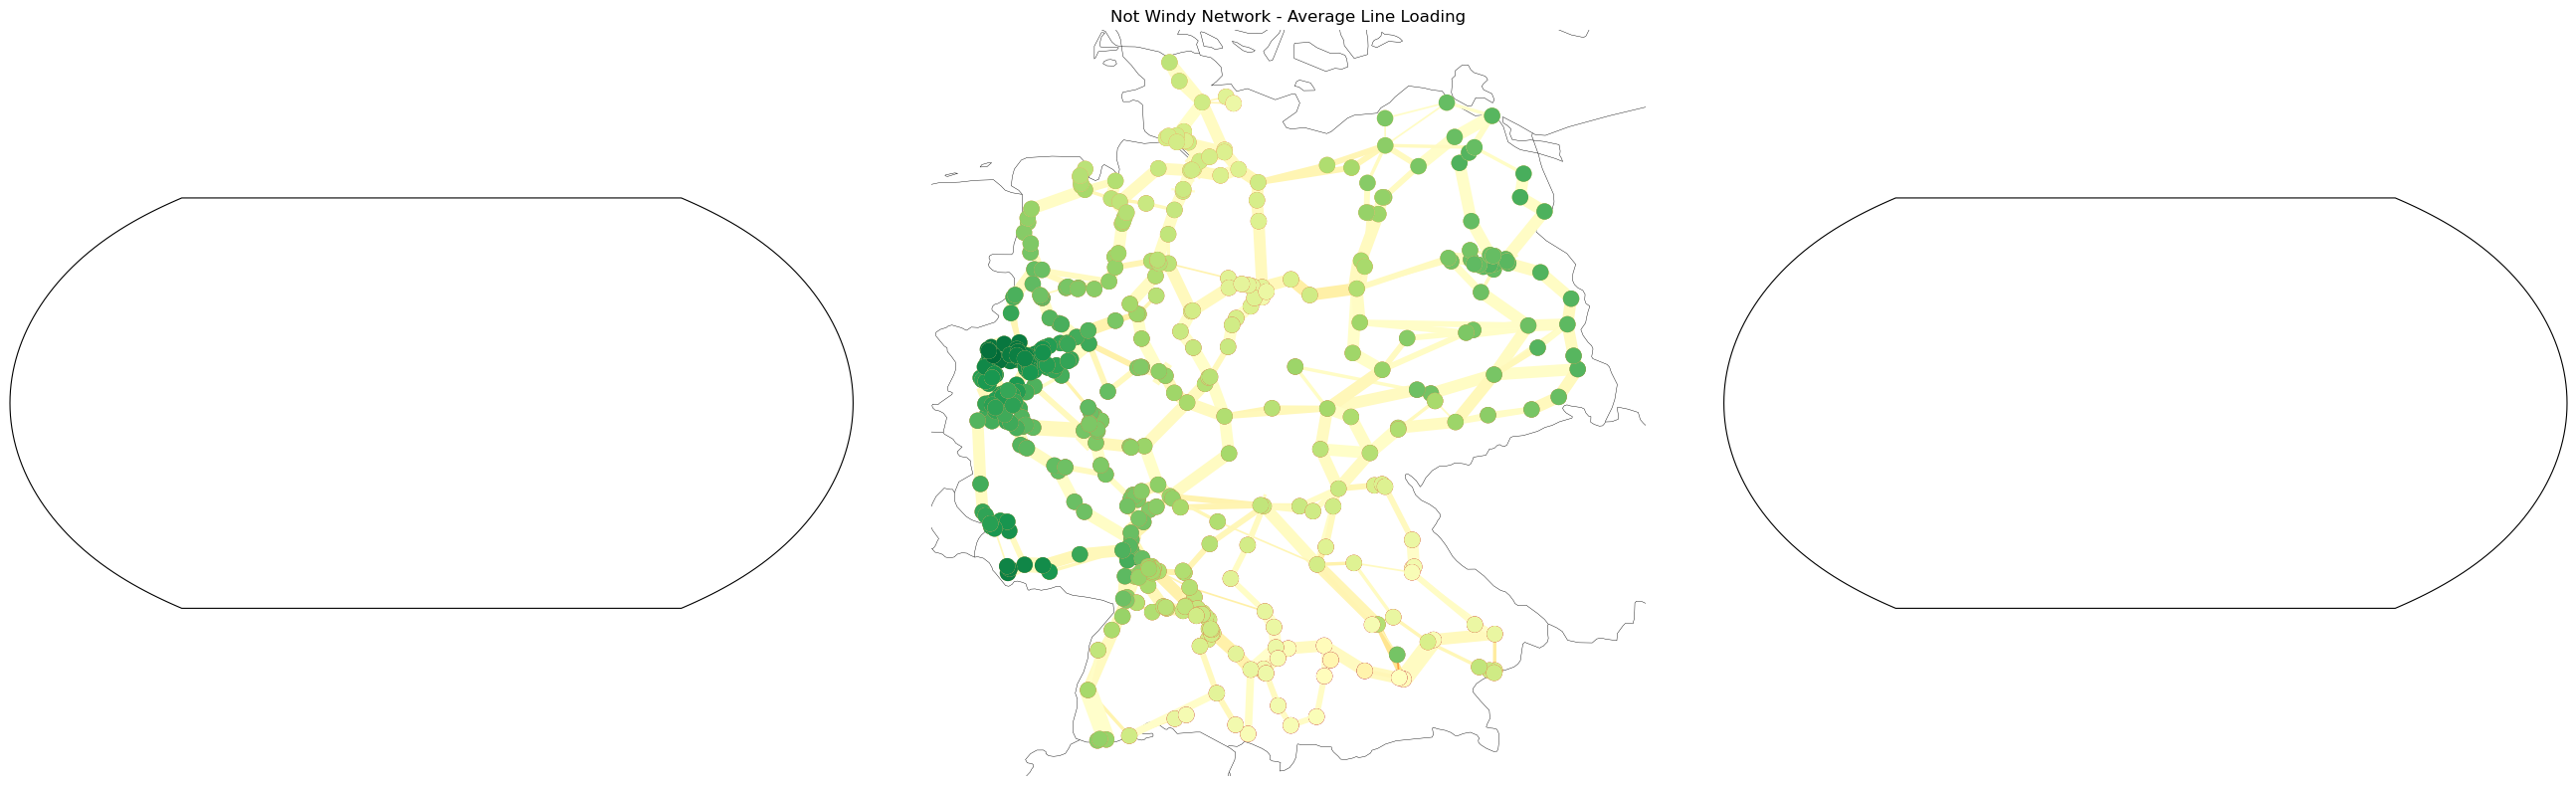

In [35]:
# --- Calculate average loading across all snapshots ---
#avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
#avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    print(loading_avg.sort_values(ascending=False).head(20))
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01, # Size buses by marginal price
        bus_colors=peak_prices,       # Color buses by marginal price
        bus_cmap='RdYlGn_r',
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network

#plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
#plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

### Load shedding

Using load-related carriers: ['load']


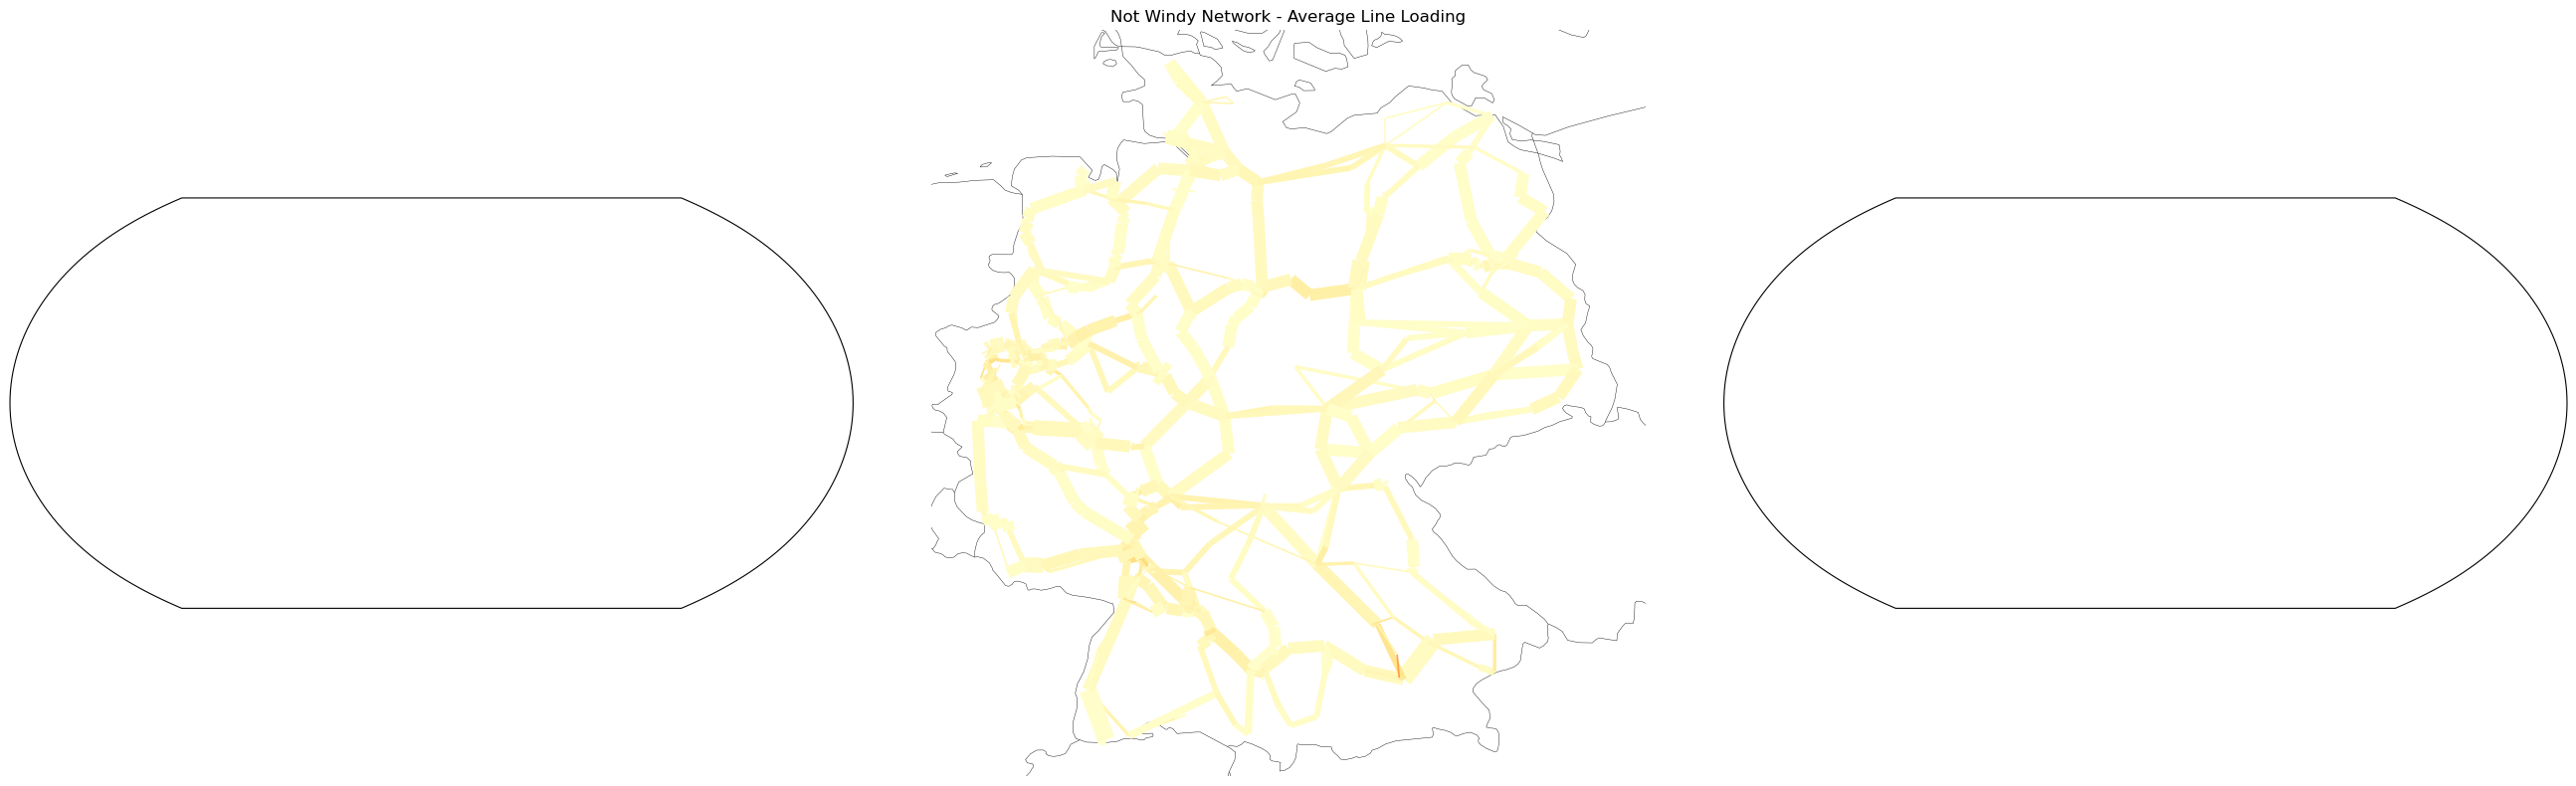

In [36]:
# --- Calculate average loading across all snapshots ---
#avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
#avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        used_carriers = sorted(n.generators.loc[shed_gens, "carrier"].unique())
        print(f"Using load-related carriers: {used_carriers}")

        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )


    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]


    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        #bus_sizes=0.01, # Size buses by unmet load at worst snapshot
        bus_sizes=unmet_load_at_snapshot/5000,
        #bus_colors=unmet_load_at_snapshot,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network
#plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
#plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

In [37]:
# --- Print congestion statistics ---
print("\n" + "=" * 70)
print("CONGESTION STATISTICS")
print("=" * 70)
print(f"\nWindy Network:")
print(f"  Average loading across all lines: {avg_loading_n1.mean():.2%}")
print(f"  Max average loading: {avg_loading_n1.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n1 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n1 > 0.7).sum()}")

print(f"\nNot Windy Network:")
print(f"  Average loading across all lines: {avg_loading_n2.mean():.2%}")
print(f"  Max average loading: {avg_loading_n2.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n2 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n2 > 0.7).sum()}")

print(f"\nWind Variability Network:")
print(f"  Average loading across all lines: {avg_loading_n3.mean():.2%}")
print(f"  Max average loading: {avg_loading_n3.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n3 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n3 > 0.7).sum()}")
print("=" * 70)


CONGESTION STATISTICS

Windy Network:


NameError: name 'avg_loading_n1' is not defined

##### Offshore Wind Curtailment

Total curtailed offwind-ac in 'Not Windy' network: 0.00 MWh
offwind-ac capacity MW: 11163.743
Total available (MWh): 8316.629597688581
Total dispatched (MWh): 8316.628220654844
Total curtailed (MWh): 0.0013770337362609686
Curtailed fraction: 1.6557593675251376e-07


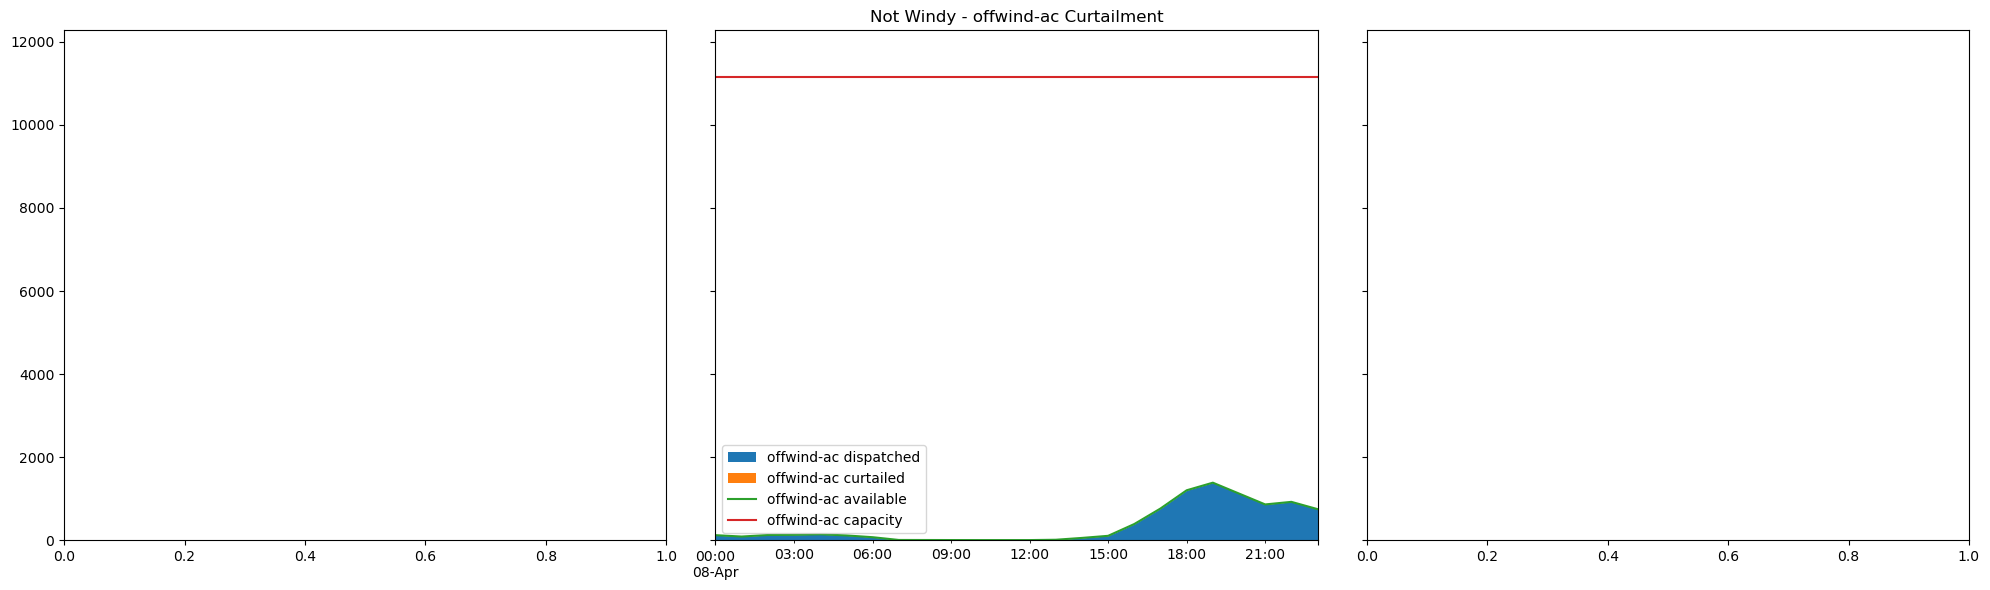

In [38]:
def plot_curtailment(n, carrier, ax):
    p_available_by_carrier = (
        n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    )
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

    # Correct for any minor negative values from floating point inaccuracies.
    p_curtailed_by_carrier[p_curtailed_by_carrier < 0] = 0

    capacity = n.generators.groupby("carrier")["p_nom"].sum().at[carrier]

    p_df = pd.DataFrame(
        {
            carrier + " available": p_available_by_carrier[carrier],
            carrier + " dispatched": p_by_carrier[carrier],
            carrier + " curtailed": p_curtailed_by_carrier[carrier],
        }
    )

    p_df[carrier + " capacity"] = capacity

    print(f"Total curtailed {carrier} in '{n.name}' network: {p_curtailed_by_carrier[carrier].sum():.2f} MWh")

    p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0)
    p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax)

    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_ylim([0, p_df[carrier + " capacity"].max() * 1.1 if hasattr(p_df[carrier + " capacity"], "max") else None])
    ax.set_title(f"{n.name} - {carrier} Curtailment")

    carrier = "offwind-ac"
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_av_by = p_available.T.groupby(n.generators.carrier).sum().T
    p_disp_by = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_cur = (p_av_by - p_disp_by).clip(lower=0)

    tot_av = p_av_by[carrier].sum()
    tot_disp = p_disp_by[carrier].sum()
    tot_cur = p_cur[carrier].sum()
    print(carrier, "capacity MW:", n.generators.groupby("carrier")["p_nom"].sum().get(carrier))
    print("Total available (MWh):", tot_av)
    print("Total dispatched (MWh):", tot_disp)
    print("Total curtailed (MWh):", tot_cur)
    print("Curtailed fraction:", tot_cur / tot_av if tot_av else float("nan"))

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

#plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
#plot_curtailment(n3, "offwind-ac", axes[2])


plt.tight_layout()
plt.show()

NameError: name 'n1' is not defined

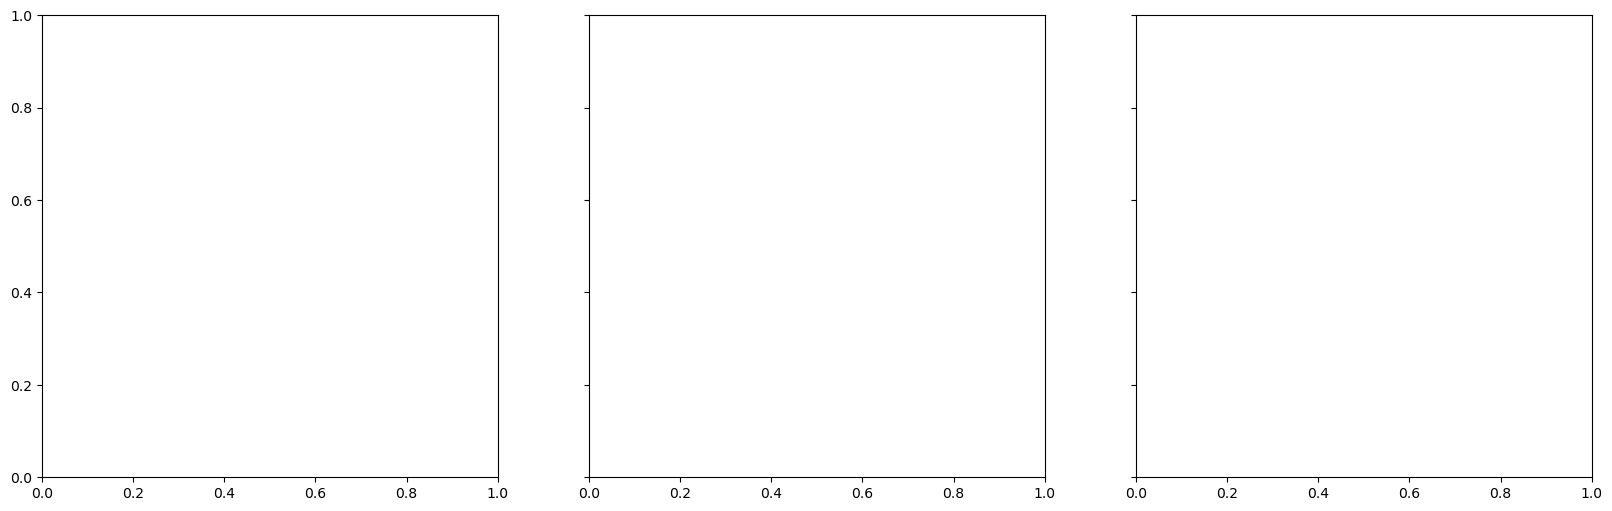

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

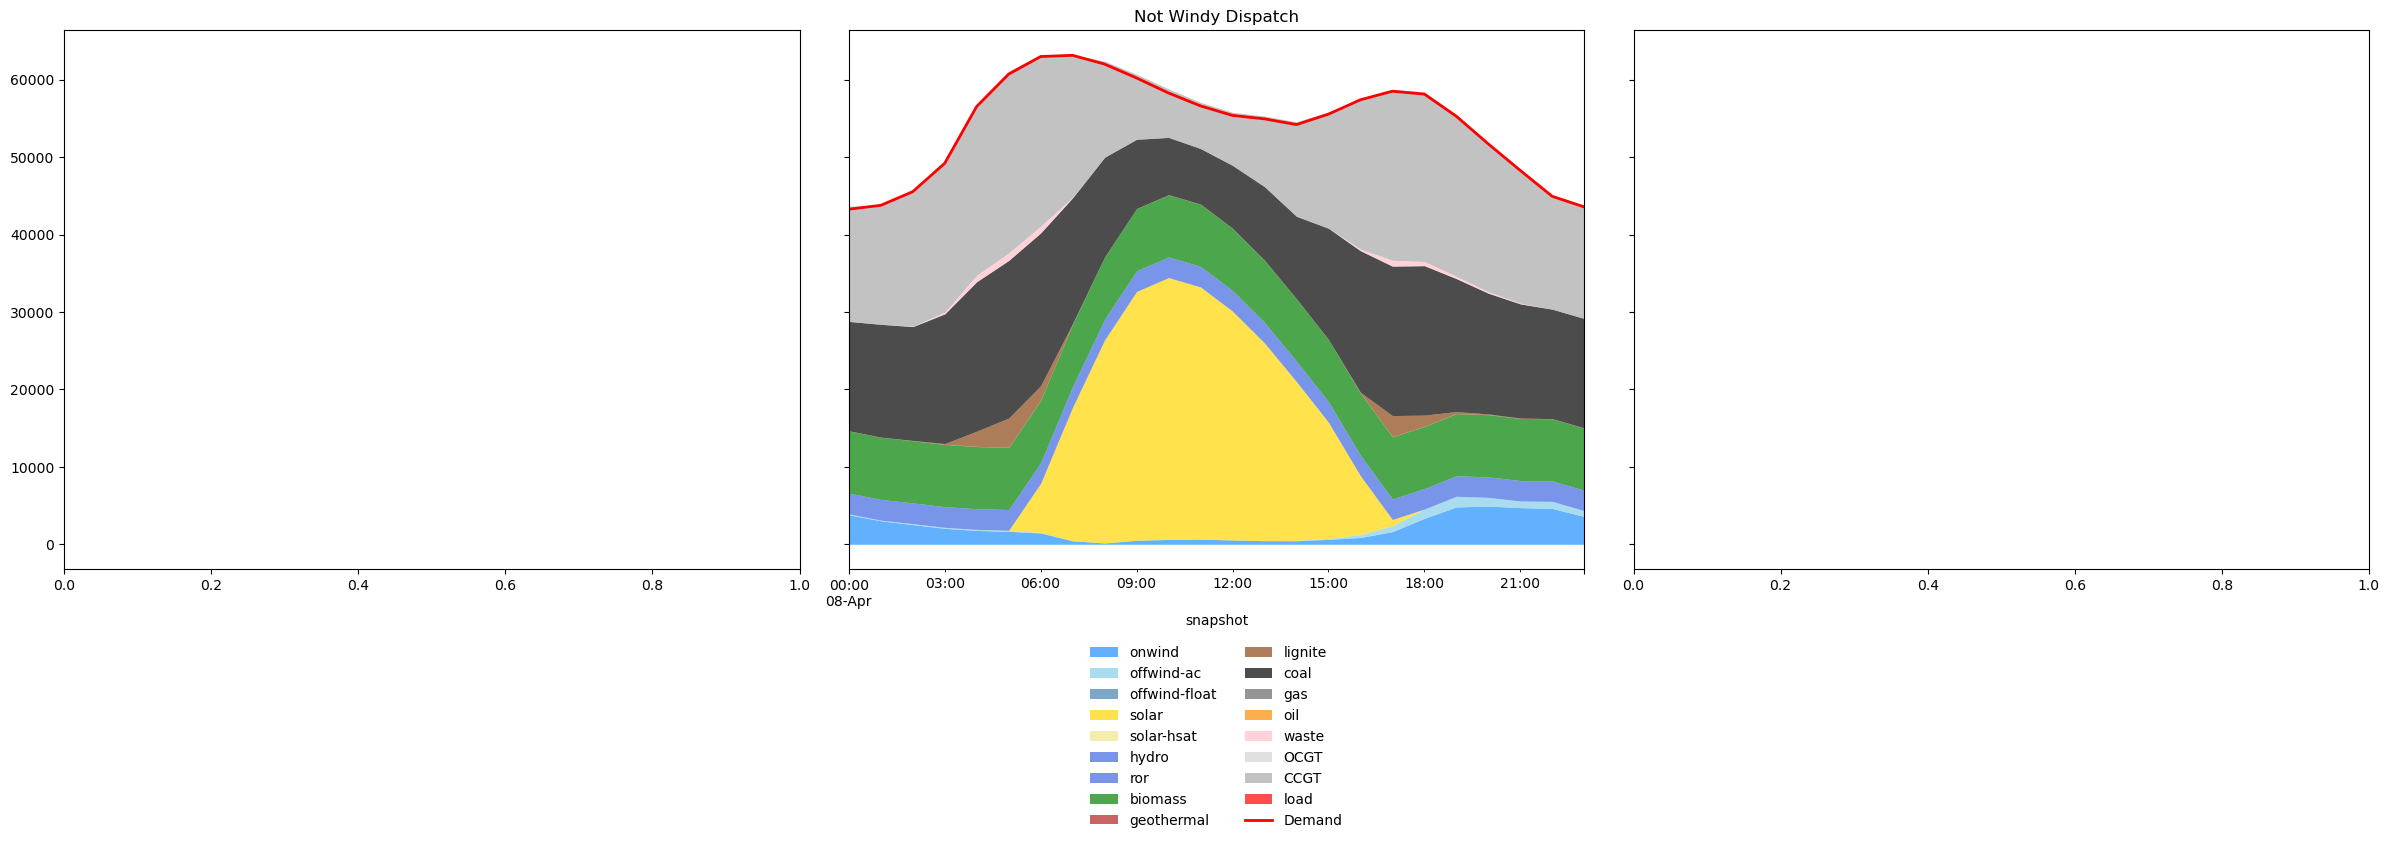

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "skyblue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "royalblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "gas": "dimgray",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    "geothermal": "firebrick",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", "offwind-float", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    # Conventional
    "lignite", "coal", "gas", "oil", "waste",
    "OCGT", "CCGT",
    # Storage
    "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
#plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
#plot_dispatch(n3, axes[2], "Wind Variability Dispatch")


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

##### Total Energy Production by Carrier

In [26]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]


# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in energy_df.index]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Base Scenario", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()

NameError: name 'n1' is not defined

In [27]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    print(f"Total CO2 emissions at the {n.name} day: {co2_emissions:.2f}")


In [29]:
calculate_emissions(n2)

Total CO2 emissions at the Not Windy day: 713738.14
